In [672]:
import numpy as np
import pandas as pd
from catboost import Pool, CatBoostRegressor
import matplotlib.pyplot as plt

In [673]:
def z_normalization(x: np.array):
    mean = np.mean(x, axis=0)
    std = np.std(x, axis=0)
    result = (x - mean) / (std + 1e-8)
    return result

def delta_x(x: np.array):
    res = []
    for i in range(1, x.shape[0]):
        delta = x[i] - x[i - 1]
        res.append(delta.tolist())
    return np.array(res)

def create_seq(x: np.array, y: np.array):
    n = 12
    result_x = []
    res_y = []
    for i in range(x.shape[0] - n):
        window = x[i:i+n]
        diff = np.diff(window, axis=0)
        result_x.append(diff.tolist())
        res_y.append(y[i+n])
    return np.array(result_x), np.array(res_y)

def prepare_target(y_raw: np.array):
    horizon = 1
    y = []
    for i in range(y_raw.shape[0] - horizon):
        diff = np.log(y_raw[i + horizon]) - np.log(y_raw[i])
        # diff = y_raw[i + horizon] - y_raw[i]
        y.append(diff)
    
    return np.array(y)

def prepare_prediction(current_gdp, prediction):
    gdp = current_gdp * np.exp(prediction)
    # gdp = current_gdp * prediction
    return gdp

In [674]:
import os

path = "data/"
directory = os.listdir(path)

In [675]:
datasets = []

for file in directory:
    if file == "NET_2.csv":
        continue
    if "_3" in file:
        continue
    if file == "FRA_1.csv":
        data4 = pd.read_csv(os.path.join(path, file))
    else:
        datasets.append(pd.read_csv(os.path.join(path, file)))

gdp_plot = []
def prepare_country_data(df):
    global gdp_plot
    gdp = df["gdp"].values
    gdp_plot.extend(gdp[12+4:])
    bad_cols = ["date", "gdp", "gdp_per_cap", "consuption", "supply", 
                 "gdp_per_reg", "goverement", "most_popular_party", "flag_name"]
    for col in bad_cols:
        if col in df.columns:
            df = df.drop([col], axis=1)
    x = df.values[:]
    return create_seq(x, gdp)


seq_X = []
seqs_y = []

for df in datasets:
    x_s, y_s = prepare_country_data(df)
    x_s = x_s[:-1]
    seq_X.append(x_s)
    seqs_y.append(prepare_target(y_s))


X = np.concatenate(seq_X, axis=0)
y = np.concatenate(seqs_y, axis=0)


X_val, y_val_raw = prepare_country_data(data4)
X_val = X_val[:-1]
y_val = prepare_target(y_val_raw)

# X_train_flat = z_normalization(X.reshape(X.shape[0], -1))
# X_val_flat = z_normalization(X_val.reshape(X_val.shape[0], -1))
X_train_flat = X.reshape(X.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

In [676]:
class OptLoss(object):
    def __init__(self):
        pass
    
    def calc_ders_range(self, approxes, targets, weights):
        assert len(approxes) == len(targets)
        if weights is not None:
            assert len(weights) == len(approxes)
    
        result = []
        for index in range(len(targets)):
            der1 = 2 * (approxes[index] - targets[index])
            penalty = -0.01 / (approxes[index] ** 2 + 1e-4)
            der1 += penalty
            der2 = 1

            if weights is not None:
                der1 *= weights[index]
                der2 *= weights[index]
                
            
            result.append((der1, der2))

        return result

    def is_max_optimal(self):
        return False

In [677]:
model = CatBoostRegressor(
    iterations=10000,
    learning_rate=3e-3,
    depth=8,
    early_stopping_rounds=300,
    verbose=50,
    loss_function='RMSE',
    eval_metric='RMSE',  
    l2_leaf_reg = 0.5,
    task_type="GPU",
)

train_pool = Pool(X_train_flat, y)
validation_pool = Pool(X_val_flat, y_val)

model.fit(train_pool, eval_set=validation_pool)

0:	learn: 0.1478240	test: 0.1321606	best: 0.1321606 (0)	total: 102ms	remaining: 17m 2s
50:	learn: 0.1455396	test: 0.1316862	best: 0.1316857 (49)	total: 4.53s	remaining: 14m 44s
100:	learn: 0.1434675	test: 0.1309868	best: 0.1309868 (100)	total: 8.62s	remaining: 14m 4s
150:	learn: 0.1416160	test: 0.1306066	best: 0.1306001 (147)	total: 12.8s	remaining: 13m 55s
200:	learn: 0.1399062	test: 0.1304120	best: 0.1304120 (200)	total: 16.9s	remaining: 13m 42s
250:	learn: 0.1381831	test: 0.1302503	best: 0.1302224 (246)	total: 21s	remaining: 13m 36s
300:	learn: 0.1366616	test: 0.1300585	best: 0.1300445 (297)	total: 25.2s	remaining: 13m 32s
350:	learn: 0.1352729	test: 0.1298623	best: 0.1298278 (340)	total: 29.3s	remaining: 13m 24s
400:	learn: 0.1339651	test: 0.1297526	best: 0.1297328 (399)	total: 33.3s	remaining: 13m 17s
450:	learn: 0.1327083	test: 0.1296064	best: 0.1296064 (450)	total: 37.4s	remaining: 13m 11s
500:	learn: 0.1315079	test: 0.1293314	best: 0.1293222 (497)	total: 41.4s	remaining: 13m 5s

CatBoostRegressor(depth=8, early_stopping_rounds=300, eval_metric='RMSE', iterations=10000, l2_leaf_reg=0.5, learning_rate=0.003, loss_function='RMSE', verbose=50)

In [678]:
data_train = pd.read_csv("data/FRA_1.csv")
y_np_t = data_train["gdp"].values
X_np_t = data_train.drop(["date","gdp", "gdp_per_cap", "consuption", "supply", "gdp_per_reg", "goverement", "most_popular_party", "flag_name"], axis=1).values

# X_z_t = z_normalization(X_np_t)
X_z_t = X_np_t

X_test, real_gdp = create_seq(X_z_t, y_np_t)

prediction = model.predict(X_test.reshape([X_test.shape[0], -1]))


true_pred = []
for i in range(real_gdp.shape[0]):
    curr = real_gdp[i]
    pred = prediction[i]
    true_pred.append(prepare_prediction(curr, pred))

true_pred = np.array(true_pred)


In [679]:
print(y.mean(), y.std())
print(prediction.mean(), prediction.std())

0.0037755363314875136 0.14787035161308063
0.002519556608527036 0.01881724875238497


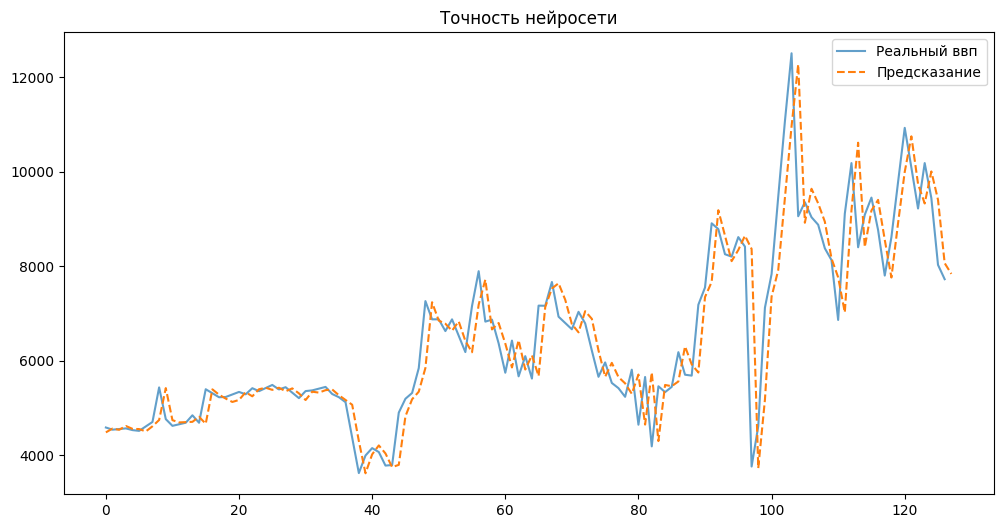

In [687]:
plt.figure(figsize=(12, 6))
ground_truth = y_np_t[12 + 1:]
plt.plot(ground_truth.tolist(), label='Реальный ввп', alpha=0.7)
plt.plot(true_pred, label='Предсказание', linestyle='--')
plt.legend()
plt.title("Точность нейросети")
plt.show()

In [681]:
print(data4["diversification"].diff().describe())

count    139.000000
mean      -0.002014
std        0.270657
min       -0.987000
25%       -0.151000
50%        0.016000
75%        0.140000
max        1.046000
Name: diversification, dtype: float64


In [682]:
importance = model.get_feature_importance()

temp = data4.copy()

bad_cols = ["date", "gdp", "gdp_per_cap", "consuption", "supply", 
                 "gdp_per_reg", "goverement", "most_popular_party", "flag_name"]
for col in bad_cols:
    if col in temp.columns:
        temp = temp.drop([col], axis=1)
names = temp.columns.tolist()

fancy = []
for n in range(11): 
    years = (11 - n) / 2
    for name in names:
        fancy.append(f"{name} в {years} год")


df = pd.DataFrame(
    {
        "features": fancy,
        "importances": importance,
    }
).sort_values(by = "importances", ascending=False)

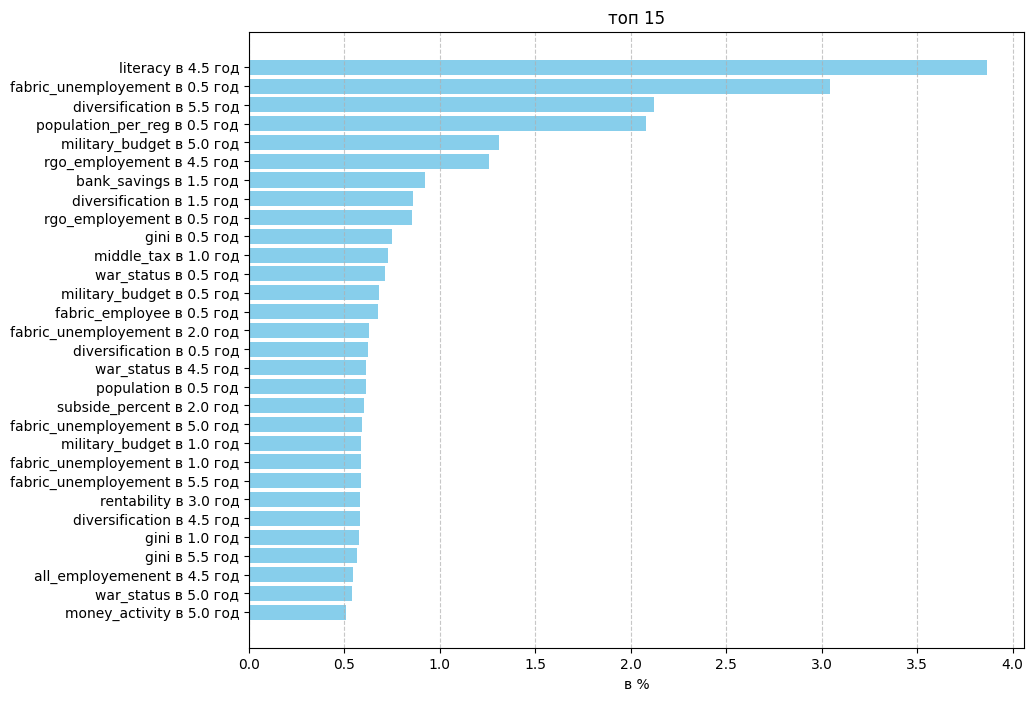

In [683]:
plt.figure(figsize=(10, 8))

top = df.head(30)

plt.barh(top["features"], top["importances"], color='skyblue')
plt.xlabel('в %')
plt.title('топ 15')
plt.gca().invert_yaxis() 
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

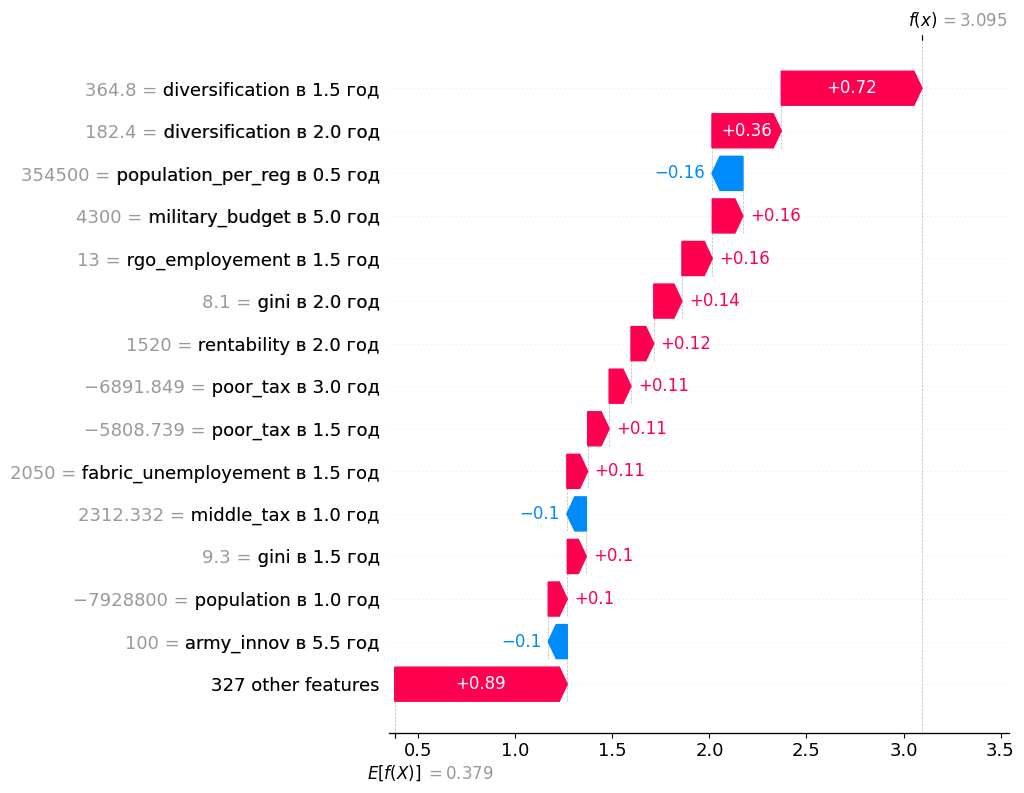

In [684]:
import shap

fancy_shap = []
for n in range(11): 
    years = (11 - n) / 2
    for name in names:
        fancy_shap.append(f"{name} в {years} год")

explainer = shap.Explainer(model)
shap_values = explainer(X_train_flat)
shap_values.feature_names = fancy_shap

shap.plots.waterfall(shap_values[50] * 100, max_display=15)

In [685]:
fname = "export_models/model"
model.save_model(fname,
                format="cbm",
                export_parameters=None,
                pool=None)